<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/Logistic-Regression/Logistic_Regression_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Logistic Regression- Scratch

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load data
iris = load_iris()
X = iris.data  # All 4 features
# Create binary target: 1 if Setosa (class 0), else 0
y = (iris.target == 0).astype(int).reshape(-1, 1)

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Add Bias
X_train_final = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]
X_test_final = np.c_[np.ones((len(X_test_scaled), 1)), X_test_scaled]

Data Processing

In [ ]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iterations=1000):
        self.lr = lr
        self.n_iterations = n_iterations
        self.weights = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros((n, 1))

        for _ in range(self.n_iterations):
            # 1. Linear combination + Sigmoid
            z = X.dot(self.weights)
            y_pred = self.sigmoid(z)

            # 2. Gradient of Log-Loss (Surprisingly, it looks just like Linear Regression!)
            gradient = (1/m) * X.T.dot(y_pred - y)

            # 3. Update
            self.weights -= self.lr * gradient

    def predict_prob(self, X):
        return self.sigmoid(X.dot(self.weights))

    def predict(self, X, threshold=0.5):
        return (self.predict_prob(X) >= threshold).astype(int)

Class of Logistic Regression

In [ ]:
# Train the model
model = LogisticRegressionScratch(lr=0.1, n_iterations=1000)
model.fit(X_train_final, y_train)

# Accuracy Calculation
y_pred_test = model.predict(X_test_final)
accuracy = np.mean(y_pred_test == y_test)
print(f"Classification Accuracy: {accuracy * 100:.2f}%")

Classification Accuracy: 100.00%


Implementation


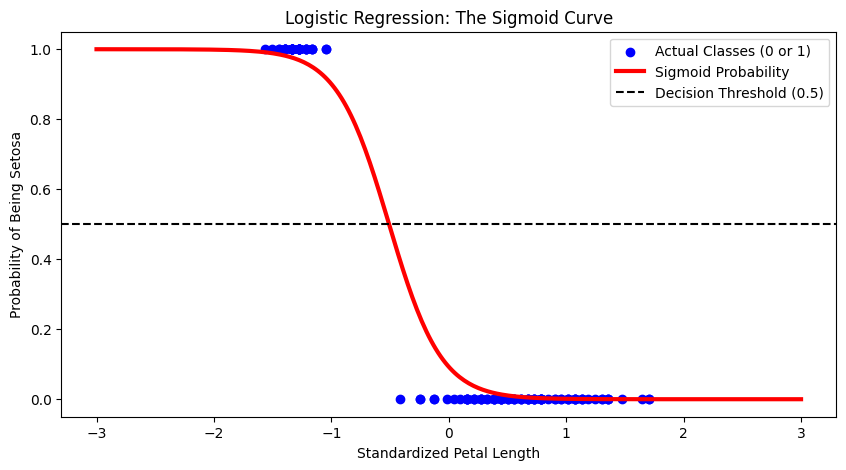

In [ ]:
import matplotlib.pyplot as plt

# We'll use just one feature (Petal Length) for a clear 2D Sigmoid curve
X_single = X_train_scaled[:, 2:3]
X_single_final = np.c_[np.ones((len(X_single), 1)), X_single]

model_2d = LogisticRegressionScratch(lr=0.1, n_iterations=1000)
model_2d.fit(X_single_final, y_train)

# Create a range of values to plot the smooth curve
X_range = np.linspace(-3, 3, 300).reshape(-1, 1)
X_range_final = np.c_[np.ones((300, 1)), X_range]
y_probs = model_2d.predict_prob(X_range_final)

plt.figure(figsize=(10, 5))
plt.scatter(X_single, y_train, color='blue', label='Actual Classes (0 or 1)')
plt.plot(X_range, y_probs, color='red', linewidth=3, label='Sigmoid Probability')
plt.axhline(y=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
plt.xlabel('Standardized Petal Length')
plt.ylabel('Probability of Being Setosa')
plt.title('Logistic Regression: The Sigmoid Curve')
plt.legend()
plt.show()

Visualization -2D

In [ ]:
import plotly.graph_objects as go

# Using Petal Length (index 2) and Petal Width (index 3)
X_2d = X_train_scaled[:, 2:4]
X_2d_final = np.c_[np.ones((len(X_2d), 1)), X_2d]

model_3d = LogisticRegressionScratch(lr=0.1, n_iterations=1000)
model_3d.fit(X_2d_final, y_train)

# Create grid for surface
x_rng = np.linspace(-2, 2, 30)
y_rng = np.linspace(-2, 2, 30)
xx, yy = np.meshgrid(x_rng, y_rng)
grid_final = np.c_[np.ones(900), xx.ravel(), yy.ravel()]

# Predict probabilities over the grid
zz = model_3d.predict_prob(grid_final).reshape(xx.shape)

fig = go.Figure(data=[
    go.Surface(x=x_rng, y=y_rng, z=zz, colorscale='RdBu', opacity=0.8),
    go.Scatter3d(x=X_2d[:, 0], y=X_2d[:, 1], z=y_train.flatten(),
                 mode='markers', marker=dict(color='black', size=4))
])

fig.update_layout(title='3D Logistic Regression Probability Surface',
                  scene=dict(xaxis_title='Petal Length', yaxis_title='Petal Width', zaxis_title='Probability'))
fig.show()

Visualization -3D

*In this first step into classification, we adapted our regression engine to handle binary outcomes. By introducing the Sigmoid function, we transformed linear outputs into probabilities. We also shifted from minimizing "distance" (MSE) to maximizing "likelihood" (Log-Loss), which penalizes the model more aggressively if it is confident about a wrong prediction. The result is a model that doesn't just draw a line through data, but identifies a Decision Boundary that best separates two distinct groups.*